In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
import os



In [16]:
# 1. Load Raw Data
# Assuming standard Kaggle Spotify Tracks Dataset with 20+ columns
df_raw = pd.read_csv('../data/spotify_tracks.csv')



In [17]:
# 2. Feature Selection (Dropping the noise)
# We remove metadata (IDs, names) and features with historically zero correlation to popularity (like time_signature)
drop_cols = ['track_id', 'artists', 'album_name', 'track_name', 'duration_ms', 'time_signature', 'mode', 'key']
df_clean = df_raw.drop(columns=drop_cols, errors='ignore')



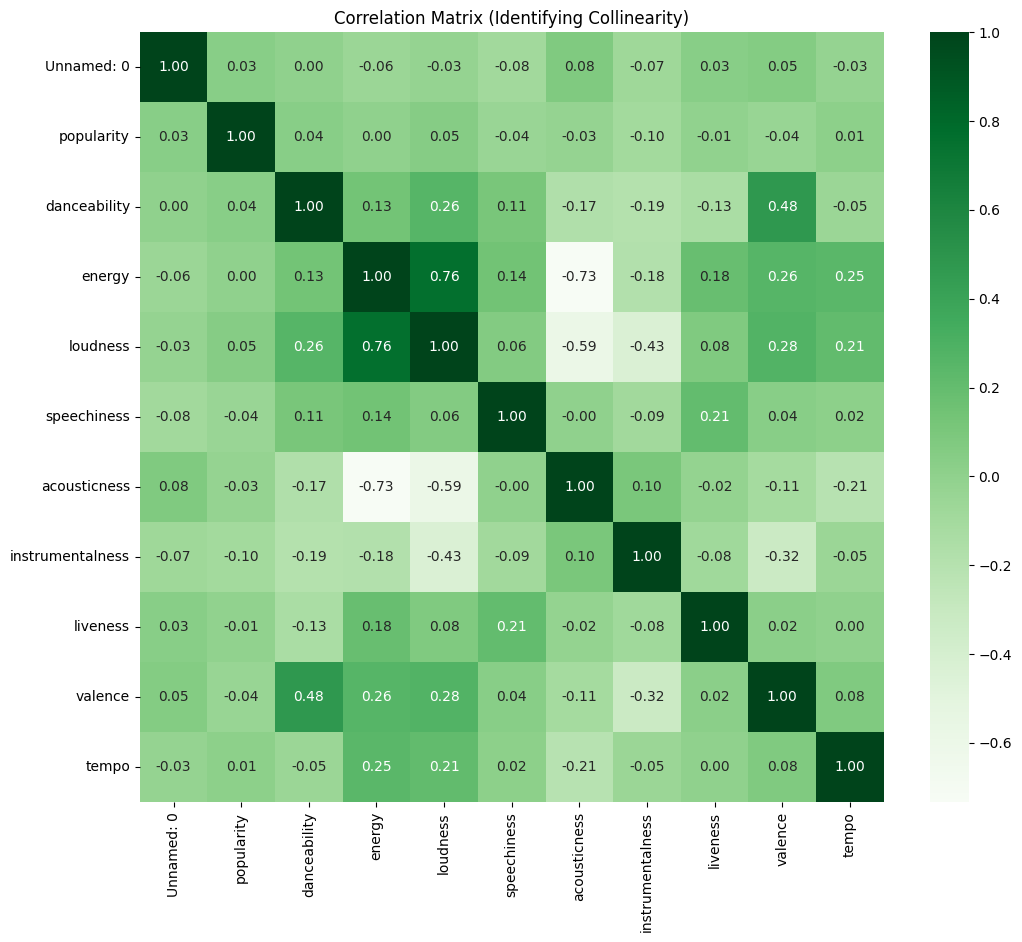

In [18]:
# 3. Correlation Analysis & Multi-collinearity Check
plt.figure(figsize=(12, 10))
numeric_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, cmap='Greens', fmt=".2f")
plt.title("Correlation Matrix (Identifying Collinearity)")
plt.show()



In [19]:
# Insight: 'loudness' and 'energy' are usually highly collinear (corr > 0.75). 
# Keeping both confuses tree-based splits. We will drop 'loudness'.
df_clean = df_clean.drop(columns=['loudness'], errors='ignore')

# 4. Feature Engineering (Adding Value)
# Create a composite metric: Tracks that are highly danceable AND highly energetic often perform differently than just one or the other.
df_clean['dance_energy_index'] = df_clean['danceability'] * df_clean['energy']



In [20]:
# 5. Save Cleaned Dataset for Production
df_clean.to_csv('../data/cleaned_spotify_tracks.csv', index=False)
print("Cleaned data saved to data/cleaned_spotify_tracks.csv")

# 6. Pipeline Prototyping
X = df_clean[['danceability', 'energy', 'valence', 'tempo', 'acousticness', 'dance_energy_index', 'track_genre']]
y = df_clean['popularity']


Cleaned data saved to data/cleaned_spotify_tracks.csv
